In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('dataset/diabetes.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (768, 9)


In [7]:
df_columns = list(df.columns)
print("Columns in the dataset:", df_columns)

Columns in the dataset: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
print("Descriptive statistics of the dataset:")
print(df.describe())

Descriptive statistics of the dataset:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.47695

In [10]:
target_col = 'Outcome'
x = df.drop(columns=[target_col])
y = df[target_col]

In [11]:
print("Class distribution in the target variable:")
print(y.value_counts())

Class distribution in the target variable:
Outcome
0    500
1    268
Name: count, dtype: int64


In [12]:
zero_counts = (x==0).sum()
print("Count of zero values in each column:")
print(zero_counts)

Count of zero values in each column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [13]:
print(zero_counts[zero_counts > 0].sort_values(ascending=False))

Insulin          374
SkinThickness    227
Pregnancies      111
BloodPressure     35
BMI               11
Glucose            5
dtype: int64


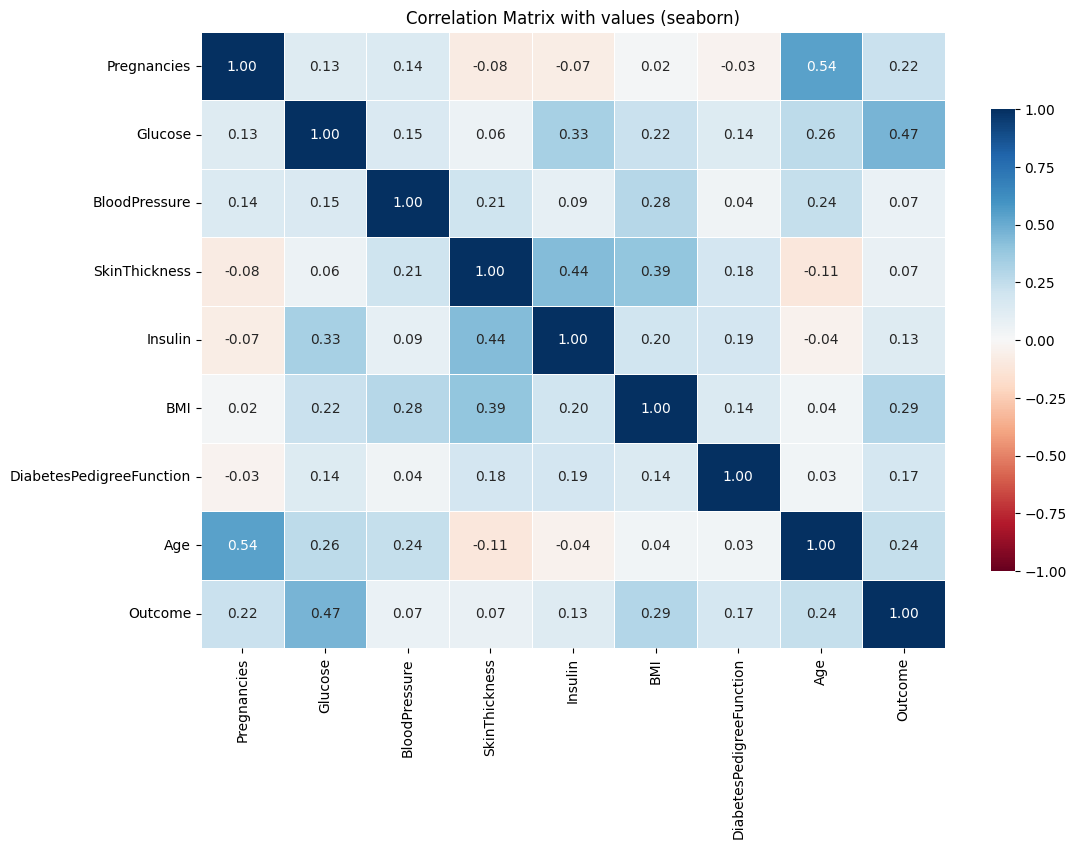

In [14]:
corr = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='RdBu', fmt=".2f",vmin=-1, vmax=1,
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.75})
plt.title('Correlation Matrix with values (seaborn)')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y, random_state=34)

In [17]:
# Case 1 with stratify
# 500 - 0, 90% of 500 --> 450(train), 50 is for left test
# 300 - 1, 90% of 300 --> 270(train), 30 is for left test

In [18]:
print(f"After split -> x_train: {x_train.shape},x_test: {x_test.shape}")

After split -> x_train: (691, 8),x_test: (77, 8)


In [19]:
numeric_cols = x.select_dtypes(include=[np.number]).columns.tolist()

In [20]:
numeric_cols.remove('Pregnancies')

In [21]:
remaining_cols = ['Pregnancies']

In [22]:
numeric_cols

['Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [23]:
remaining_cols

['Pregnancies']

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.compose import ColumnTransformer

In [25]:
transformer = []

In [26]:
impute_then_scale = SklearnPipeline([
    ("imputer_zero_as_missing", SimpleImputer(missing_values=0, strategy='median')),
    ("scaler", StandardScaler())
])
transformer.append(('impute_scale', impute_then_scale, numeric_cols))

In [27]:
scale_preg = SklearnPipeline([
    ("scaler_all", StandardScaler()),
])
transformer.append(('scaler_all', scale_preg, remaining_cols))

In [28]:
preprocessor = ColumnTransformer(transformers=transformer, remainder='drop')

In [29]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_scale', ...), ('scaler_all', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and 

## Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
clf = LogisticRegression(max_iter=1000, solver='liblinear', random_state=20)

In [32]:
pipeline = SklearnPipeline([("preprocessor", preprocessor), ("clf", clf)])

In [33]:
pipeline.fit(x_train, y_train)
# preprocessor.fit(x_train)
# preprocessor.transform(x_train)
# clf.fit(x_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_scale', ...), ('scaler_all', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [34]:
# si = SimpleImputer(missing_values=0, strategy='median')
# ss = StandardScaler()
# clf = LogisticRegression(max_iter=1000, solver='liblinear', random_state=20)

# si = si.fit(x_train)
# x_train = si.transform(x_train)

# ss = ss.fit(x_train)
# x_train = ss.transform(x_train)

# clf = clf.fit(x_train, y_train)
# y_train_pred = clf.predict(x_train)

In [35]:
y_train_pred = pipeline.predict(x_train)
y_test_pred = pipeline.predict(x_test)

In [36]:
y_train_pred

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,

In [37]:
y_train_proba_diab = pipeline.predict_proba(x_train)[:, 1]
# 0 > No
# 1 > Yes

In [38]:
y_train_proba_diab

array([0.05507721, 0.59269046, 0.12154196, 0.68461217, 0.32012302,
       0.72882314, 0.69541756, 0.23800347, 0.12277848, 0.96319672,
       0.51376313, 0.20765799, 0.67743397, 0.27034231, 0.08939735,
       0.12254243, 0.31622108, 0.2526256 , 0.09536678, 0.23563632,
       0.91516293, 0.57333869, 0.14396789, 0.09496592, 0.23264544,
       0.75576418, 0.55738175, 0.13917215, 0.34777151, 0.0684724 ,
       0.13179319, 0.04216027, 0.46433929, 0.10482766, 0.10387291,
       0.85981065, 0.21855276, 0.21713334, 0.46181029, 0.05598485,
       0.19190998, 0.01454832, 0.84087934, 0.03374344, 0.18593107,
       0.03142412, 0.10133828, 0.13285887, 0.03660754, 0.04044446,
       0.41395241, 0.36371563, 0.3090345 , 0.37592566, 0.30412964,
       0.420376  , 0.075777  , 0.88629739, 0.22968927, 0.20942962,
       0.2456127 , 0.03941401, 0.56760757, 0.40167246, 0.89817827,
       0.97238356, 0.15240479, 0.39172876, 0.01708409, 0.18191745,
       0.45010928, 0.07321894, 0.89281795, 0.93595468, 0.15773

In [39]:
(y_train_proba_diab >= 0.9).astype(int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [40]:
y_test_proba_diab = pipeline.predict_proba(x_test)[:, 1]
y_test_proba_diab

array([0.64879555, 0.11700982, 0.78103819, 0.39671969, 0.62176831,
       0.84885642, 0.06407105, 0.12215847, 0.0390365 , 0.67853518,
       0.05128474, 0.86821947, 0.19952315, 0.12487191, 0.91265058,
       0.90891171, 0.12393063, 0.16254568, 0.29185999, 0.36151939,
       0.64408913, 0.72359386, 0.28183815, 0.10912441, 0.06520466,
       0.76425846, 0.26334779, 0.20606344, 0.66668102, 0.16576752,
       0.24394159, 0.13708993, 0.8996522 , 0.11150798, 0.68797751,
       0.32573846, 0.20824843, 0.06686689, 0.3595455 , 0.28528814,
       0.21207893, 0.08917325, 0.07817576, 0.09180929, 0.83289397,
       0.09072002, 0.12432354, 0.05020604, 0.89245791, 0.20580764,
       0.22519189, 0.87331726, 0.33463061, 0.06866184, 0.01548122,
       0.20257996, 0.78195838, 0.06481439, 0.15856296, 0.24566399,
       0.1445738 , 0.96597763, 0.7253239 , 0.09339346, 0.04704508,
       0.0315345 , 0.12214915, 0.53241433, 0.16288027, 0.30977205,
       0.32679455, 0.07433082, 0.72775018, 0.67947813, 0.10531

In [41]:
train_results = x_train.copy()
train_results['Actual'] = y_train.values
train_results['Predicted'] = y_train_pred
train_results['Predicted_Probability'] = y_train_proba_diab

In [42]:
test_results = x_test.copy()
test_results['Actual'] = y_test.values
test_results['Predicted'] = y_test_pred
test_results['Predicted_Probability'] = y_test_proba_diab

In [43]:
print("TRAIN RESULTS:")
train_results.head()

TRAIN RESULTS:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Predicted_Probability
353,1,90,62,12,43,27.2,0.580,24,0,0,0.055077
281,10,129,76,28,122,35.9,0.280,39,0,1,0.592690
644,3,103,72,30,152,27.6,0.730,27,0,0,0.121542
231,6,134,80,37,370,46.2,0.238,46,1,1,0.684612
468,8,120,0,0,0,30.0,0.183,38,1,0,0.320123


In [44]:
print("TEST RESULTS:")
test_results.head()

TEST RESULTS:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Predicted_Probability
417,4,144,82,32,0,38.5,0.554,37,1,1,0.648796
562,1,87,68,34,77,37.6,0.401,24,0,0,0.117010
40,3,180,64,25,70,34.0,0.271,26,0,1,0.781038
199,4,148,60,27,318,30.9,0.150,29,1,0,0.396720
179,5,130,82,0,0,39.1,0.956,37,1,1,0.621768


In [45]:
test_results[test_results['Actual'] != test_results['Predicted']]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Predicted_Probability
40,3,180,64,25,70,34.0,0.271,26,0,1,0.781038
199,4,148,60,27,318,30.9,0.150,29,1,0,0.396720
41,7,133,84,0,0,40.2,0.696,37,0,1,0.678535
469,6,154,78,41,140,46.1,0.571,27,0,1,0.868219
660,10,162,84,0,0,27.7,0.182,54,0,1,0.723594
630,7,114,64,0,0,27.4,0.732,34,1,0,0.281838
70,2,100,66,20,90,32.9,0.867,28,1,0,0.165768
659,3,80,82,31,70,34.2,1.292,27,1,0,0.137090
419,3,129,64,29,115,26.4,0.219,28,1,0,0.208248
664,6,115,60,39,0,33.7,0.245,40,1,0,0.359546


In [46]:
test_results[test_results['Actual'] != test_results['Predicted']].shape

(14, 11)

In [47]:
test_results.groupby(['Actual', 'Predicted']).size()

Actual  Predicted
0       0            45
        1             5
1       0             9
        1            18
dtype: int64

In [48]:
from sklearn.metrics import(
accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score,
confusion_matrix, classification_report
)

In [49]:
def compute_metrics(y_true, y_pred):
    return{
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "ROC-AUC Score": roc_auc_score(y_true, y_pred),
        "classification_report": classification_report(y_true, y_pred, output_dict=True)
    }

In [50]:
metrics_train = compute_metrics(y_train, y_train_pred)
for k,v in metrics_train.items():
    if k not in ['confusion_matrix', 'classification_report']:
        print(f"{k}: {v:.4f}")

accuracy: 0.7713
precision: 0.7219
recall: 0.5602
f1_score: 0.6308
ROC-AUC Score: 0.7223


In [51]:
metrics_test = compute_metrics(y_test, y_test_pred)
for k,v in metrics_test.items():
    if k not in ['confusion_matrix', 'classification_report']:
        print(f"{k}: {v:.4f}")

accuracy: 0.8182
precision: 0.7826
recall: 0.6667
f1_score: 0.7200
ROC-AUC Score: 0.7833


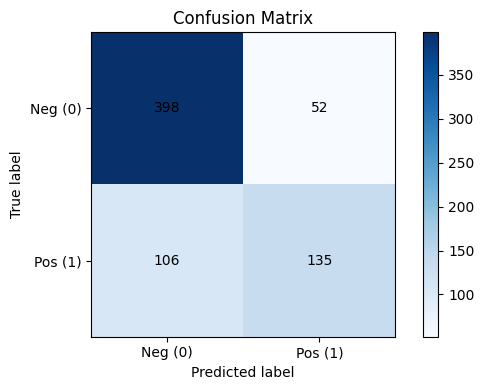

In [52]:
# Confusion Matrix
cm_train = metrics_train['confusion_matrix']
plt.figure(figsize=(6, 4))
plt.imshow(cm_train, interpolation='nearest', cmap="Blues")
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0,1], ["Neg (0)","Pos (1)"])
plt.yticks([0,1], ["Neg (0)","Pos (1)"])
for i in range(cm_train.shape[0]):
    for j in range(cm_train.shape[1]):
        plt.text(j, i, cm_train[i, j], ha="center", va="center", color="black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

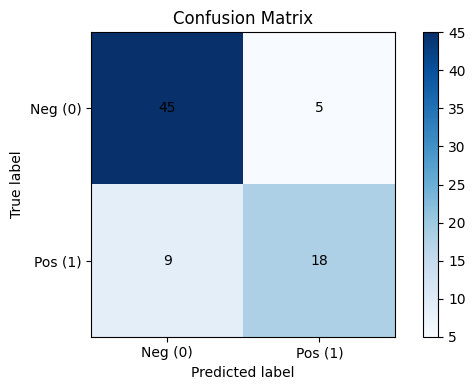

In [53]:
# Confusion Matrix
cm_test = metrics_test['confusion_matrix']
plt.figure(figsize=(6, 4))
plt.imshow(cm_test, interpolation='nearest', cmap="Blues")
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0,1], ["Neg (0)","Pos (1)"])
plt.yticks([0,1], ["Neg (0)","Pos (1)"])
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        plt.text(j, i, cm_test[i, j], ha="center", va="center", color="black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [64]:
fpr_train, tpr_train, threshold_train = roc_curve(y_train, y_train_proba_diab)
fpr_test, tpr_test, threshold_test = roc_curve(y_test, y_test_proba_diab)

In [65]:
fpr_train

array([0.        , 0.        , 0.        , 0.00222222, 0.00222222,
       0.00444444, 0.00444444, 0.00666667, 0.00666667, 0.00888889,
       0.00888889, 0.01111111, 0.01111111, 0.01333333, 0.01333333,
       0.01555556, 0.01555556, 0.01777778, 0.01777778, 0.02      ,
       0.02      , 0.02222222, 0.02222222, 0.02666667, 0.02666667,
       0.02888889, 0.02888889, 0.03111111, 0.03111111, 0.03333333,
       0.03333333, 0.03555556, 0.03555556, 0.04222222, 0.04222222,
       0.04444444, 0.04444444, 0.04666667, 0.04666667, 0.04888889,
       0.04888889, 0.05777778, 0.05777778, 0.06      , 0.06      ,
       0.07333333, 0.07333333, 0.07555556, 0.07555556, 0.07777778,
       0.07777778, 0.08444444, 0.08444444, 0.08666667, 0.08666667,
       0.08888889, 0.08888889, 0.09333333, 0.09333333, 0.10222222,
       0.10222222, 0.10444444, 0.10444444, 0.10888889, 0.10888889,
       0.11333333, 0.11333333, 0.11555556, 0.11555556, 0.12222222,
       0.12222222, 0.12888889, 0.12888889, 0.13111111, 0.13111

In [66]:
threshold_train

array([       inf, 0.99310909, 0.96082014, 0.95692065, 0.94855562,
       0.94747427, 0.9352555 , 0.93235102, 0.92151949, 0.92040752,
       0.91516293, 0.90358012, 0.89817827, 0.89634748, 0.86154646,
       0.85981065, 0.80402264, 0.8032488 , 0.80244714, 0.80240659,
       0.78801372, 0.78711201, 0.78530943, 0.78257557, 0.75778202,
       0.75729606, 0.75723365, 0.75597149, 0.75576418, 0.75216464,
       0.74171747, 0.74096803, 0.73109359, 0.72541878, 0.71056144,
       0.70333227, 0.68938073, 0.68881773, 0.67743397, 0.6771752 ,
       0.66875878, 0.65548845, 0.65054843, 0.64834204, 0.64274633,
       0.63022149, 0.62923027, 0.62671797, 0.61363195, 0.60815568,
       0.59553778, 0.59225792, 0.59165699, 0.58883811, 0.58370908,
       0.58005092, 0.5797536 , 0.5767302 , 0.56760757, 0.55823336,
       0.55738175, 0.55079571, 0.5426484 , 0.54053926, 0.52958372,
       0.52119626, 0.50913641, 0.507773  , 0.49220391, 0.48768573,
       0.48242503, 0.47784791, 0.4733495 , 0.47104578, 0.45553

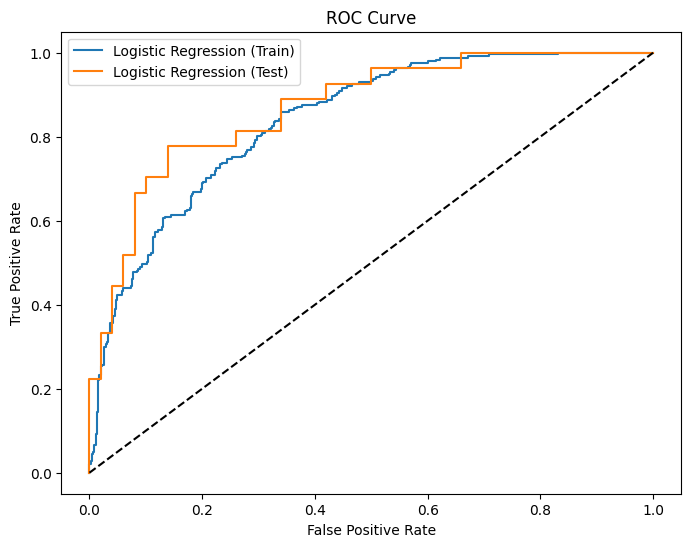

In [67]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label="Logistic Regression (Train)")
plt.plot(fpr_test, tpr_test, label="Logistic Regression (Test)")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Save Model

In [54]:
import joblib

In [55]:
output_path = "logistic_pipeline.pkl"
joblib.dump(pipeline, output_path)
print(f"Pipeline saved to {output_path}")


Pipeline saved to logistic_pipeline.pkl


In [56]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_scale', ...), ('scaler_all', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [57]:
pipeline['clf'].coef_.flatten()

array([ 1.14103141, -0.09854738,  0.09780599, -0.12414018,  0.59982454,
        0.22263566,  0.15015355,  0.39319913])

In [58]:
pipeline['clf'].intercept_

array([-0.84910137])